## Seepage Model Comparison


This notebook compares two models for seepage as a function of the water-level difference 
between estuary and ocean (Δh) and estuary water level ($h_e$) using an effective berm conductance $C$.




### Model-comparison approaches


1. *Pooled fit*: one parameter set fit to all closure events.  
2. *Per-event fits:* parameters estimated separately within each closure event; results summarized across events.

### Evaluation

- *Information criteria:* *sum* event-level AIC/BIC for per-event fits (equivalently, sum $(-2\log L$) and add penalties).  
- *Goodness of fit:* report $R^2$ and RMSE; provide unweighted and duration-weighted summaries across events.



visitor center model best performance; evaluated both bootstapping and AIC/BIC

In [30]:

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import register_matplotlib_converters
import numpy as np

register_matplotlib_converters()
plt.style.use('ggplot')

import sys
sys.path.append('/Users/octaviacrompton/Google_Drive_quatratavia/estuaries_jenner/russian-river-seepage/src/')

%matplotlib inline

# plt.rcParams['figure.figsize'] = (12.0, 6.0)
for mod in ['plot_config', 'timeseries_functions', 'seepage_analysis', 'seepage_plots']:
    if mod in sys.modules:
        del sys.modules[mod]

import plot_config
from timeseries_functions import *


mpl.rcParams['figure.dpi'] = 300

root = '/Users/octaviacrompton/Google_Drive_quatratavia/estuaries_jenner/russian-river-seepage/'

In [31]:
# ==============================================
# Seepage vs Δh / visitor_h
# Global bounds + Global x_ref + n-weighted grouped medians
# SSE loss
# ==============================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (12.0, 6.0)

# -----------------------------
# Config
# -----------------------------
data_path = Path("../data/processed/pooled_event_df.csv")  # update to path
eps = 1e-5
min_n_per_event = 5                       # min days to include an event in grouped fits

# -----------------------------
# Data loading / preparation
# -----------------------------
df = pd.read_csv(data_path)
df["delta_h"] = pd.to_numeric(df.get("delta_h"), errors="coerce")
df["seepage"] = pd.to_numeric(df.get("seepage"), errors="coerce")
df["visitor_h"] = pd.to_numeric(df.get("visitor_h"), errors="coerce")


# minimal clean
df = df.dropna(subset=["delta_h", "seepage", "visitor_h"]).copy().query("seepage < 5")

# per-event row counts
df["n"] = df.groupby("event")["event"].transform("size").astype("int64")

print(f"Rows: {len(df):,} | Events: {df['event'].nunique():,}")


Rows: 419 | Events: 32


In [32]:
# make sure 'date' is datetime (if it's not already)
df["date"] = pd.to_datetime(df["date"])

# add year and month (numeric)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month


In [33]:
df.query("year == 2018 and month == 11")

,date,seepage,delta_h,waveHs,visitor_h,Q,rain_vol,date.1,event,n,year,month
67,2018-11-01,2.319262,2.188430,0.402330,3.104804,3.404769,0.000000,2018-11-01,2,27,2018,11
68,2018-11-02,1.925318,2.194513,0.334742,3.150711,3.289397,6.236660,2018-11-02,2,27,2018,11
69,2018-11-03,2.554945,2.199401,0.350413,3.173349,3.102536,6.255244,2018-11-03,2,27,2018,11
70,2018-11-04,2.077978,2.218123,0.342360,3.208268,3.176626,6.274636,2018-11-04,2,27,2018,11
71,2018-11-05,2.513625,2.225366,0.384099,3.230626,3.064479,0.000000,2018-11-05,2,27,2018,11
72,2018-11-06,2.223752,2.225934,0.378406,3.261455,3.052409,6.299062,2018-11-06,2,27,2018,11
73,2018-11-07,2.559059,2.228390,0.334041,3.282151,3.113102,6.328448,2018-11-07,2,27,2018,11
74,2018-11-08,2.380613,2.250769,0.339634,3.312446,3.213834,0.000000,2018-11-08,2,27,2018,11
75,2018-11-09,2.497539,2.278511,0.324461,3.333147,3.054805,0.000000,2018-11-09,2,27,2018,11
76,2018-11-10,2.967608,2.242388,0.226642,3.345527,3.246717,0.000000,2018-11-10,2,27,2018,11


In [34]:

# -----------------------------
# Global x_ref per predictor
# -----------------------------
visitor_h_ref = float(np.nanmedian(df["visitor_h"].values)) 

# -----------------------------
# Global offset bounds (per predictor)
# -----------------------------
def compute_global_offset_bounds(x_series: pd.Series):
    """
    Lower bound ensures (x + offset) >= ~0 everywhere;
    Upper bound is a site-scale cap informed by data spread.
    """
    x = x_series.to_numpy(float)
    if not np.isfinite(x).any():
        return 0.0, site_cap
    lb = - float(np.nanmin(x)) + 1e-3  # keep base >= 0
    q05, q95 = np.nanquantile(x, [0.05, 0.95])
    spread = float(max(q95 - q05, 1e-6))
    ub = 0.3*spread
    
    return float(lb), float(ub)

offset_lb_vis, offset_ub_vis = compute_global_offset_bounds(df["visitor_h"])

print(f"Global x_ref (visitor h) = {visitor_h_ref:.4f}" if np.isfinite(visitor_h_ref) 
          else "Global x_ref (visitor h) = N/A")
print(f"visitor $h$ offset bounds:  [{offset_lb_vis:.4f}, {offset_ub_vis:.4f}]" )

# -----------------------------
# Helpers
# -----------------------------
def r2_centered(y, yhat):
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    sst = np.sum((y - np.mean(y))**2)
    if sst <= 0:
        return np.nan
    sse = np.sum((y - yhat)**2)
    return 1.0 - sse / sst

def weighted_median(values, weights):
    """n-weighted median (by event-duration) across closure events."""
    v = np.asarray(values, float)
    w = np.asarray(weights, float)
    ok = np.isfinite(v) & np.isfinite(w) & (w > 0)
    v, w = v[ok], w[ok]
    if len(v) == 0:
        return np.nan
    order = np.argsort(v)
    v, w = v[order], w[order]
    cw = np.cumsum(w) / np.sum(w)
    return float(v[np.searchsorted(cw, 0.5)])


# Models
def model_linear(C, x):
    return C * x

def model_offset_power_delta_h(C, offset, b, x_dh, delta_h_ref):
    """
    Offset–power model where conductance depends on Δh:

    S = C * Δh * ((Δh + offset) / (Δh_ref + offset))^b
    """    
    base = np.maximum(x_dh + offset, eps)
    xref = max(delta_h_ref + offset, eps)
    return C * x_dh * np.power(base / xref, b)

def model_offset_power_visitor_h(C, offset, b, x_dh, x_vis, visitor_h_ref):
    """
    Offset–power model where conductance depends on estuary level h_e:

    S = C * Δh * ((h_e + offset) / (h_ref + offset))^b
    """
    base = np.maximum(x_vis + offset, eps)
    xref = max(visitor_h_ref + offset, eps)
    return C * x_dh * np.power(base / xref, b)

# SSE objectives 
def sse_offset_power_delta_h(theta, x_dh, y, delta_h_ref, lb, ub):
    """
    Sum of squared errors (SSE) objective for the Δh-based offset–power model.
    """
    C, off, b = theta
    if (C <= 0) or (b < 0) or (off < lb) or (off > ub):
        return 1e99
    yhat = model_offset_power_delta_h(C, off, b, x_dh, delta_h_ref)
    resid = y - yhat
    return float(np.sum(resid * resid))

def sse_offset_power_visitor_h(theta, x_dh, x_vis, y, visitor_h_ref, lb, ub):
    """
    Sum of squared errors (SSE) objective for the h_e-based offset–power model.
    """
    C, off, b = theta
    if (C <= 0) or (b < 0) or (off < lb) or (off > ub):
        return 1e99
    yhat = model_offset_power_visitor_h(C, off, b, x_dh, x_vis, visitor_h_ref)
    resid = y - yhat
    return float(np.sum(resid * resid))

# -----------------------------
# Pooled fits (SSE)
# -----------------------------
def pooled_linear_delta_h(df_in):    
    """
    Simple linear seepage model:

        S = C * x    
    """
    x = df_in["delta_h"].to_numpy(float)
    y = df_in["seepage"].to_numpy(float)
    
    # Closed-form through-origin OLS
    denom = max(np.dot(x, x), eps)
    C = float(np.dot(x, y) / denom)
    C = max(C, 1e-12)
    yhat = model_linear(C, x)
    
    return {"C": C, "R2": r2_centered(y, yhat), "n": len(x)}

# def pooled_offset_power_delta_h(df_in):
#     """
#     Fit the pooled offset–power model where conductance depends on Δh:

#         S = C * Δh * ((Δh + offset) / (Δh_ref + offset))^b

#     using all rows in `df_in` at once (no event grouping).

#     Returns dictionary with fitted parameters and diagnostics:
#           - "C"      : base conductance at Δh_ref
#           - "offset" : offset applied to Δh inside the power term
#           - "b"      : exponent controlling sensitivity to Δh
#           - "R2"     : centered R² for the pooled fit
#           - "n"      : number of points used in the fit
          
#     """
#     # Predictor and response as 1D float arrays
#     x = df_in["delta_h"].to_numpy(float)
#     y = df_in["seepage"].to_numpy(float)

#     # Initial guess for C: ordinary least-squares slope C ≈ (x·y) / (x·x)
#     C0 = float(np.dot(x, y) / max(np.dot(x, x), eps))
#     off0 = (offset_lb_dh + offset_up_dh) / 2.0
#     # Initial guess for exponent b
#     b0 = 0.5
#     # Minimize sum of squared errors for the offset–power model in Δh
#     res = minimize(
#         sse_offset_power_delta_h,
#         x0=[max(C0, 1e-12), off0, b0],
#         args=(x, y, delta_h_ref, offset_lb_dh, offset_up_dh),
#         bounds=[(1e-12, None), (offset_lb_dh, offset_up_dh), (1e-12, None)],
#         method="L-BFGS-B",
#     )

#     # Extract fitted parameters
#     C, off, b = map(float, res.x)

#     # Fitted values for diagnostic R²
#     yhat = model_offset_power_delta_h(C, off, b, x, delta_h_ref)

#     return {
#         "C": C,
#         "offset": off,
#         "b": b,
#         "R2": r2_centered(y, yhat),
#         "n": len(x),
#     }


def pooled_offset_power_visitor_h(df_in):
    """
    Fit the pooled offset–power model where conductance depends on estuary level h_e:

        S = C * Δh * ((h_e + offset) / (h_ref + offset))^b

    using all rows in `df_in` with non-missing visitor_h.    
    """
    if not df_in["visitor_h"].notna().any():
        return {}
    # Work on subset with valid visitor_h values
    sub = df_in.dropna(subset=["visitor_h"]).copy()

    # Predictors: Δh and h_e, response: seepage S
    x = sub["delta_h"].to_numpy(float)
    xv = sub["visitor_h"].to_numpy(float)
    y = sub["seepage"].to_numpy(float)

    # Initial guess for C: OLS slope using Δh alone
    C0 = float(np.dot(x, y) / max(np.dot(x, x), eps))
    
    # Initial guess for offset: mid-point of allowed offset range for visitor_h
    off0 = (offset_lb_vis + offset_ub_vis) / 2.0
    # Initial guess for exponent b
    b0 = 0.5
   # Minimize SSE for the offset–power model in h_e 
    res = minimize(
        sse_offset_power_visitor_h,
        x0=[max(C0, 1e-12), off0, b0],
        args=(x, xv, y, visitor_h_ref, offset_lb_vis, offset_ub_vis),
        bounds=[(1e-12, None), (offset_lb_vis, offset_ub_vis), (1e-12, None)],
        method="L-BFGS-B",
    )
    C, off, b = map(float, res.x)
    yhat = model_offset_power_visitor_h(C, off, b, x, xv, visitor_h_ref)
    return {"C": C, "offset": off, "b": b, "R2": r2_centered(y, yhat), "n": len(x)}

# -----------------------------
# Optimize parameters by minimizing SSE with bounds:
# - Offset–power: `C ≥ 0`
# - Linear: `C ≥ 0`
# -----------------------------
pooled_lin = pooled_linear_delta_h(df)
pooled_vis = pooled_offset_power_visitor_h(df)

print("\n=== Pooled (global bounds, global x_ref) ===")
print(f"Linear (Δh):                 C={pooled_lin['C']:.2f},   R²={pooled_lin['R2']:.2f}, n={pooled_lin['n']}")
print(f"Offset–Power (visitor_h):    C={pooled_vis['C']:.2f}, off= {pooled_vis['offset']:.2f}, b={pooled_vis['b']:.2f}, R²={pooled_vis['R2']:.2f}, n={pooled_vis['n']}")


Global x_ref (visitor h) = 2.6718
visitor $h$ offset bounds:  [-1.7191, 0.4082]

=== Pooled (global bounds, global x_ref) ===
Linear (Δh):                 C=1.07,   R²=0.45, n=419
Offset–Power (visitor_h):    C=1.04, off= -1.72, b=0.19, R²=0.48, n=419


In [35]:
# -----------------------------
# Grouped per-event fits (SSE)
# -----------------------------
def fit_grouped_sse(df_in, min_n = min_n_per_event):
    """
    Fit seepage–Δh models separately for each closure event.

    For each event with at least `min_n` points, this function:
      1. Fits a linear model in Δh with a closed-form slope.
      2. Fits an offset–power model where conductance depends on Δh.
      3. Fits an offset–power model where conductance depends on visitor_h (h_e),
         when enough non-missing visitor_h are available.
    """    
    rows_lin = []
#     rows_dh  = []
    rows_vis = []

    # Pre-check for visitor_h availability
    vis_available = df_in["visitor_h"].notna().any()

    for ev, g in df_in.groupby("event"):
        n = int(len(g))
        if n < min_n:
            continue

        x = g["delta_h"].to_numpy(float)
        y = g["seepage"].to_numpy(float)

        # Linear (Δh) — closed form
        C_lin = float(np.dot(x, y) / max(np.dot(x, x), eps))
        C_lin = max(C_lin, 1e-12)
        yhat_l = model_linear(C_lin, x)
        rows_lin.append({"event": ev, "n": n, "C_lin":
                         C_lin, "R2_lin": r2_centered(y, yhat_l)})

        # Offset–Power (visitor_h)
        xv = g["visitor_h"].to_numpy(float)
        if np.isfinite(xv).sum() >= min_n:
            C0v = C_lin
            off0v = (offset_lb_vis + offset_ub_vis) / 2.0
            b0v = 0.5
            res_v = minimize(
                sse_offset_power_visitor_h,
                x0=[C0v, off0v, b0v],
                args=(x, xv, y, visitor_h_ref, offset_lb_vis, offset_ub_vis),
                bounds=[(1e-12, None), (offset_lb_vis, offset_ub_vis), (1e-12, None)],
            )

            Cv, offv, bv = map(float, res_v.x)
            yhat_v = model_offset_power_visitor_h(Cv, offv, bv, x, xv, visitor_h_ref)
            rows_vis.append({"event": ev, "n": n, "C": Cv, "offset": offv, "b": bv, 
                             "R2": r2_centered(y, yhat_v)})

    ev_lin = pd.DataFrame(rows_lin).sort_values("event").reset_index(drop=True)
    ev_vis = pd.DataFrame(rows_vis).sort_values("event").reset_index(drop=True) if \
                rows_vis else pd.DataFrame()
    return ev_lin, ev_vis


# -----------------------------
# n-weighted medians of grouped fits
# -----------------------------
def summarize_grouped_weighted_medians(ev_lin, ev_vis):
    """
    Compute n-weighted medians of per-event parameters for each model family.
    """
    out = {}

    if not ev_lin.empty:
        out["Linear (Δh)"] = {
            "C": weighted_median(ev_lin["C_lin"].values, ev_lin["n"].values)
        }

    if not ev_vis.empty:
        out["Offset–Power (visitor_h)"] = {
            "C":       weighted_median(ev_vis["C"].values, ev_vis["n"].values),
            "offset":  weighted_median(ev_vis["offset"].values, ev_vis["n"].values),
            "b":       weighted_median(ev_vis["b"].values, ev_vis["n"].values),
        }

    return out
        
offset_lb_vis = pooled_vis['offset'] - 0.5
offset_ub_vis = pooled_vis['offset'] + 0.5

ev_lin, ev_vis = fit_grouped_sse(df, min_n=min_n_per_event)
wmed = summarize_grouped_weighted_medians(ev_lin, ev_vis)

# -----------------------------
# Comparison table (pooled vs grouped w-med)
# -----------------------------
rows = []

# Linear (Δh)
rows.append({
    "Model": "Linear (Δh)",
    "Pooled C": pooled_lin["C"],
    "Grouped C": wmed.get("Linear (Δh)", {}).get("C", np.nan),
})

# Offset–Power (visitor_h)
rows.append({
    "Model": "Offset–Power (visitor_h)",
    "Pooled C":      pooled_vis["C"],
    "Grouped C":      wmed.get("Offset–Power (visitor_h)", {}).get("C", np.nan),
    "Pooled offset": pooled_vis["offset"],
    "Grouped offset": wmed.get("Offset–Power (visitor_h)", {}).get("offset", np.nan),
    "Pooled b":      pooled_vis["b"],
    "Grouped b":      wmed.get("Offset–Power (visitor_h)", {}).get("b", np.nan),
})

comp = pd.DataFrame(rows)
num_cols = comp.select_dtypes(include=[float, int]).columns
comp[num_cols] = comp[num_cols].round(3)
comp[num_cols] = comp[num_cols].mask(np.isclose(comp[num_cols], 0.0, atol=5e-4), 0.0)

print("\n=== Comparison (Pooled vs Grouped n-weighted medians) ===")
comp


=== Comparison (Pooled vs Grouped n-weighted medians) ===


,Model,Pooled C,Grouped C,Pooled offset,Grouped offset,Pooled b,Grouped b
0,Linear (Δh),1.069,1.021,NaN,NaN,NaN,NaN
1,Offset–Power (visitor_h),1.045,0.937,-1.717,-1.457,0.189,0.142


ev_vis - note no negative R2 values. find closure event that created negatives in the initial submission, and then


In [54]:
# --- (optional) if you need to bring the visitor_h fit params into `summary` ---
# ev_vis has: event, n, C, offset, b, R2
summary = ev_lin.merge(
    ev_vis[["event", "offset", "b", "R2"]].rename(
        columns={"offset": "offset_best", "b": "b_best", "R2": "best_R2"}
    ),
    on="event",
    how="left",
)

# Format the new parameter for display (match your K_tilde_fmt pattern)
summary["offset_fmt"] = summary["offset_best"].map(lambda v: f"{v:.2f}" if pd.notna(v) else "")

# print(
#     summary[["date", "duration", "N", "K_tilde_fmt", "R2", "offset_fmt", "b_best", "best_R2"]]
#       .to_latex(index=False)
#       .replace("midrule", "hline")
#       .replace("toprule", "hline")
#       .replace("bottomrule", "hline")
#       .replace("K_tilde_fmt", "$\\tilde K$")
#       .replace("R2", "$R^2$")
#       .replace("offset_fmt", "$\\mathrm{offset}_{V,\\mathrm{optim}}$")
#       .replace("b_best", "$b_{\\mathrm{optim}}$")
#       .replace("best_R2", "$R^2_{\\mathrm{optim}}$")
#       .replace("{llllllll}", "{lllll|lll}")  # 8 columns now
# )


In [55]:
summary

,event,n,C_lin,R2_lin,offset_best,b_best,best_R2,offset_fmt
0,0,28,0.789944,0.367967,-1.442189,1.000000e-12,0.367967,-1.44
1,1,25,0.947261,0.641615,-2.180870,1.132688e-01,0.732506,-2.18
2,2,27,1.021473,0.708041,-1.216779,3.688342e-01,0.748216,-1.22
3,3,23,0.896598,0.039563,-1.216779,1.000000e-12,0.039563,-1.22
4,4,21,1.090512,0.788652,-2.181204,1.525268e-01,0.858543,-2.18
5,5,17,1.176926,0.366796,-1.901950,9.409692e-02,0.386968,-1.90
6,6,18,0.928514,0.724254,-1.718593,1.423927e-01,0.775576,-1.72
7,7,17,0.564746,0.579942,-1.562703,1.862225e-01,0.608894,-1.56
8,8,21,0.745839,0.516382,-1.456671,6.455237e-01,0.646327,-1.46
9,9,22,1.657880,0.863587,-1.602685,1.000000e-12,0.863587,-1.60


### Model comparison: Information criteria (AIC/BIC) using SSE

In [37]:
# --------------------------------
# IC helper: SSE, AIC, BIC
# --------------------------------
def compute_ic(y, yhat, k):
    """
    Compute SSE, AIC, and BIC for a given model fit.
    
    Parameters
    ----------
    y, yhat : array-like
        Observed and predicted values.
    k : int
        Number of free parameters in the model.
        
    Returns
    -------
    dict with keys: n, sse, R2, AIC, BIC
    """
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    ok = np.isfinite(y) & np.isfinite(yhat)
    y, yhat = y[ok], yhat[ok]
    n = len(y)
    if n == 0:
        return {"n": 0, "sse": np.nan, "R2": np.nan, "AIC": np.nan, "BIC": np.nan}
    
    sse = float(np.sum((y - yhat)**2))
    r2  = r2_centered(y, yhat)
    
    sigma2 = sse / n
    aic = n * np.log(sigma2) + 2 * k
    bic = n * np.log(sigma2) + k * np.log(n)
    
    return {"n": n, "sse": sse, "R2": r2, "AIC": aic, "BIC": bic}


# --------------------------------
# Pooled model comparison: AIC/BIC (full dataset)
# --------------------------------
x_all  = df["delta_h"].to_numpy(float)
xv_all = df["visitor_h"].to_numpy(float)
y_all  = df["seepage"].to_numpy(float)

# Predictions from pooled fits
yhat_lin  = model_linear(pooled_lin["C"], x_all)
yhat_vis  = model_offset_power_visitor_h(
    pooled_vis["C"], pooled_vis["offset"], pooled_vis["b"],
    x_all, xv_all, visitor_h_ref
)

stats_lin = compute_ic(y_all, yhat_lin,  k=1)  # C
stats_vis = compute_ic(y_all, yhat_vis,  k=3)  # C, offset, b

comp_ic = pd.DataFrame([
    {"Model": "Linear (Δh)",           **stats_lin},
#     {"Model": "Offset–Power (Δh)",     **stats_dh},
    {"Model": "Offset–Power (visitor)",**stats_vis},
])

print("\n=== Pooled model comparison (full dataset) ===")
display(comp_ic.round(3).sort_values("AIC"))


best = comp_ic.sort_values("AIC").iloc[0]
comp_ic["dAIC_vs_linear"] = comp_ic["AIC"] - stats_lin["AIC"]
comp_ic["dBIC_vs_linear"] = comp_ic["BIC"] - stats_lin["BIC"]
comp_ic.drop('n', axis = 1).iloc[1:].round(3)


=== Pooled model comparison (full dataset) ===


,Model,n,sse,R2,AIC,BIC
1,Offset–Power (visitor),419,152.646,0.477,-417.085,-404.971
0,Linear (Δh),419,161.039,0.449,-398.657,-394.620


,Model,sse,R2,AIC,BIC,dAIC_vs_linear,dBIC_vs_linear
1,Offset–Power (visitor),152.646,0.477,-417.085,-404.971,-18.428,-10.352


Akaike’s Information Criterion (AIC) and the Bayesian Information Criterion (BIC)  score models by trading off goodness of fit against complexity: both start from the fit error (here, SSE) and add a penalty for the number of free parameters $k$, so smaller values are better. AIC uses a lighter penalty term $2k$ and is oriented toward predictive performance, whereas BIC uses a stronger penalty $k \ln n$ and more harshly discourages extra parameters, especially when the number of observations $n$ is large. In both cases, only differencesd matter: $\Delta \mathrm{AIC}$ or $\Delta \mathrm{BIC}$ of about 2 are weak, 4–7 moderate, and $>10$ strong evidence for the model with the lower value.

Using AIC/BIC assumes data are independent and identically distributed, and that residuals are roughly Gaussian with constant variance and not too strongly autocorrelated. With moderate violations, AIC/BIC are still commonly used as heuristic tools rather than strict tests.

Above, both nonlinear models outperform the linear $\Delta h$ model, with $\Delta \mathrm{AIC} \approx -19$ to $-26$ and $\Delta \mathrm{BIC} \approx -11$ to $-18$ relative to linear, which is strong support for the nonlinear forms. Among them, the visitor center offset–power model has the lowest AIC and BIC and is therefore the preferred pooled seepage–head model.


### 1. Interpreting AIC and BIC outputs 

---

* AIC (Akaike Information Criterion)
  $\text{AIC} = n \ln(\tfrac{\text{SSE}}{n}) + 2k$
  where $n$ is sample size, SSE the sum of squared residuals, and $k$ the number of free parameters.
  
     * Lower AIC means better expected **out-of-sample predictive accuracy** (minimizes KL divergence).
     * AIC penalizes complexity with $2k$.

* BIC (Bayesian Information Criterion)
  $\text{BIC} = n \ln(\tfrac{\text{SSE}}{n}) + k \ln n$
  
     *  Lower BIC means stronger evidence for the model under a Bayesian marginal likelihood approximation.
     *  BIC penalizes complexity more heavily than AIC (because $k \ln n \gg 2k$ when $n$ is large).

---

Assumptions: AIC and BIC both derive from the same likelihood framework:

* Residuals are independent, identically distributed, Gaussian with constant variance.
* Models are fit by maximum likelihood (least-squares regression used here satisfies this).
* AIC’s information-theoretic foundation is predictive (best for model comparison, not “truth”).
* BIC’s Bayesian foundation is evidence-based (tries to approximate posterior probability of models).
* Absolute AIC/BIC values are meaningless — only differences (ΔAIC, ΔBIC) matter.

---
How to interpret these numbers:


* If ΔAIC < 0: the offset–power model is preferred (strongly if Δ ≤ −10).
* If ΔAIC > 0: the linear model is preferred.
  
  Rules of thumb for ΔAIC:
  * 0–2: negligible support
  * 4–7: some support
  * ≥10: strong/decisive support

* If ΔBIC < 0: offset–power is preferred; ΔBIC > 0: linear is preferred.
  BIC is harsher on complexity, so if ΔAIC is slightly negative (favoring offset–power) but ΔBIC is positive (favoring linear), it means:

* If ΔAIC is small (say −2) and ΔBIC is positive, then the offset–power adds complexity without convincing gains → stick with linear.
* If ΔAIC is very negative (≤−10), then the extra parameters clearly buy predictive accuracy, even if BIC is still skeptical.


In [38]:
# --------------------------------
# Helper: fit all pooled models on a given dataframe
# --------------------------------
def fit_pooled_all(df_in):
    """
    Fit linear, Δh-power, and visitor_h-power pooled models on df_in
    and return parameters + R2 + SSE for each.
    """
    # Fit using your existing pooled functions
    plin = pooled_linear_delta_h(df_in)
    pvis = pooled_offset_power_visitor_h(df_in)

    # Data arrays
    x  = df_in["delta_h"].to_numpy(float)
    xv = df_in["visitor_h"].to_numpy(float)
    y  = df_in["seepage"].to_numpy(float)

    # Predictions
    yhat_lin = model_linear(plin["C"], x)
    yhat_vis = model_offset_power_visitor_h(
        pvis["C"], pvis["offset"], pvis["b"],
        x, xv, visitor_h_ref
    )

    # SSEs
    sse_lin = float(np.sum((y - yhat_lin)**2))
    sse_vis = float(np.sum((y - yhat_vis)**2))

    out = {
        "lin": {
            "C": plin["C"],
            "R2": r2_centered(y, yhat_lin),
            "SSE": sse_lin,
        },
        "vis": {
            "C": pvis["C"],
            "offset": pvis["offset"],
            "b": pvis["b"],
            "R2": r2_centered(y, yhat_vis),
            "SSE": sse_vis,
        },
    }
    return out

# --------------------------------
# Bootstrap differences in SSE and R2
# --------------------------------
def bootstrap_pooled_diffs(df, n_boot=500, random_state=0, cluster_by_event=True):
    """
    Bootstrap differences in SSE and R2 between models.

    If cluster_by_event=True, resample whole events (blocC bootstrap).
    Otherwise, resample individual rows (i.i.d. bootstrap).
    """
    rng = np.random.default_rng(random_state)
    records = []

    if cluster_by_event:
        events = df["event"].unique()
        n_events = len(events)

    for b in range(n_boot):
        # --- resample data ---
        if cluster_by_event:
            boot_events = rng.choice(events, size=n_events, replace=True)
            boot_df = pd.concat(
                [df[df["event"] == ev] for ev in boot_events],
                ignore_index=True,
            )
        else:
            idx = rng.integers(0, len(df), size=int(len(df)*0.8))
            boot_df = df.iloc[idx].reset_index(drop=True)

        # --- fit all pooled models on bootstrap sample ---
        fits = fit_pooled_all(boot_df)

        # --- store differences vs linear ---
        rec = {
            "iter": b,
            "n":    len(boot_df),
            # SSE differences (negative means nonlinear model has smaller SSE)
            "dSSE_vis_vs_lin": fits["vis"]["SSE"] - fits["lin"]["SSE"],
            # R2 differences (positive means nonlinear model explains more variance)
            "dR2_vis_vs_lin":  fits["vis"]["R2"]  - fits["lin"]["R2"],
        }
        records.append(rec)

    return pd.DataFrame(records)
# --------------------------------
# Summarize bootstrap results
# --------------------------------
boot = bootstrap_pooled_diffs(df, n_boot=500, random_state=123, cluster_by_event=False)
boot.head()
def summarize_boot_diffs(boot_df):
    stats = {}
    cols = [
#             "dSSE_dh_vs_lin", 
            "dSSE_vis_vs_lin",
#             "dR2_dh_vs_lin",  
            "dR2_vis_vs_lin"]
    for col in cols:
        vals = boot_df[col].to_numpy(float)
        stats[col] = {
            "mean":   float(np.mean(vals)),
            "median": float(np.median(vals)),
            "p2.5":   float(np.quantile(vals, 0.025)),
            "p97.5":  float(np.quantile(vals, 0.975)),
        }
    return pd.DataFrame(stats).T.round(3)

boot_summary = summarize_boot_diffs(boot)
boot_summary



,mean,median,p2.5,p97.5
dSSE_vis_vs_lin,-7.177,-6.620,-14.191,-2.635
dR2_vis_vs_lin,0.030,0.029,0.013,0.055


In [39]:
# --------------------------------
# Bootstrap differences in SSE and R2
# --------------------------------
def bootstrap_pooled_diffs(df, n_boot=500, random_state=0, cluster_by_event=False):
    """
    Bootstrap differences in SSE and R2 between models.

    If cluster_by_event=True, resample whole events (block bootstrap).
    Otherwise, resample individual rows (i.i.d. bootstrap).
    """
    rng = np.random.default_rng(random_state)
    records = []

    if cluster_by_event:
        events = df["event"].unique()
        n_events = len(events)

    for b in range(n_boot):
        # --- resample data ---
        if cluster_by_event:
            boot_events = rng.choice(events, size=n_events, replace=True)
            boot_df = pd.concat(
                [df[df["event"] == ev] for ev in boot_events],
                ignore_index=True,
            )
        else:
            idx = rng.integers(0, len(df), size=int(len(df) * 0.8))
            boot_df = df.iloc[idx].reset_index(drop=True)

        # --- fit all pooled models on bootstrap sample ---
        fits = fit_pooled_all(boot_df)

        # --- store differences ---
        rec = {
            "iter": b,
            "n":    len(boot_df),

            # vs linear (negative dSSE = better than linear; positive dR2 = better than linear)
            "dSSE_vis_vs_lin":  fits["vis"]["SSE"] - fits["lin"]["SSE"],
            "dR2_vis_vs_lin":   fits["vis"]["R2"]  - fits["lin"]["R2"]
        }
        records.append(rec)

    return pd.DataFrame(records)

# --------------------------------
# Summarize bootstrap results
# --------------------------------
def summarize_boot_diffs(boot_df):
    """
    Summarize bootstrap differences in SSE and R² between models.
    """
    stats = {}
    cols = [ 
        "dSSE_vis_vs_lin",    
        "dR2_vis_vs_lin"
    ]
    for col in cols:
        vals = boot_df[col].to_numpy(float)
        stats[col] = {
            "mean":   float(np.mean(vals)),
            "median": float(np.median(vals)),
            "p2.5":   float(np.quantile(vals, 0.025)),
            "p97.5":  float(np.quantile(vals, 0.975)),
        }
    return pd.DataFrame(stats).T.round(3)

boot = bootstrap_pooled_diffs(df, n_boot=500, random_state=123, cluster_by_event=True)
boot_summary = summarize_boot_diffs(boot)
boot_summary

,mean,median,p2.5,p97.5
dSSE_vis_vs_lin,-9.134,-8.354,-21.150,-0.985
dR2_vis_vs_lin,0.031,0.030,0.004,0.068


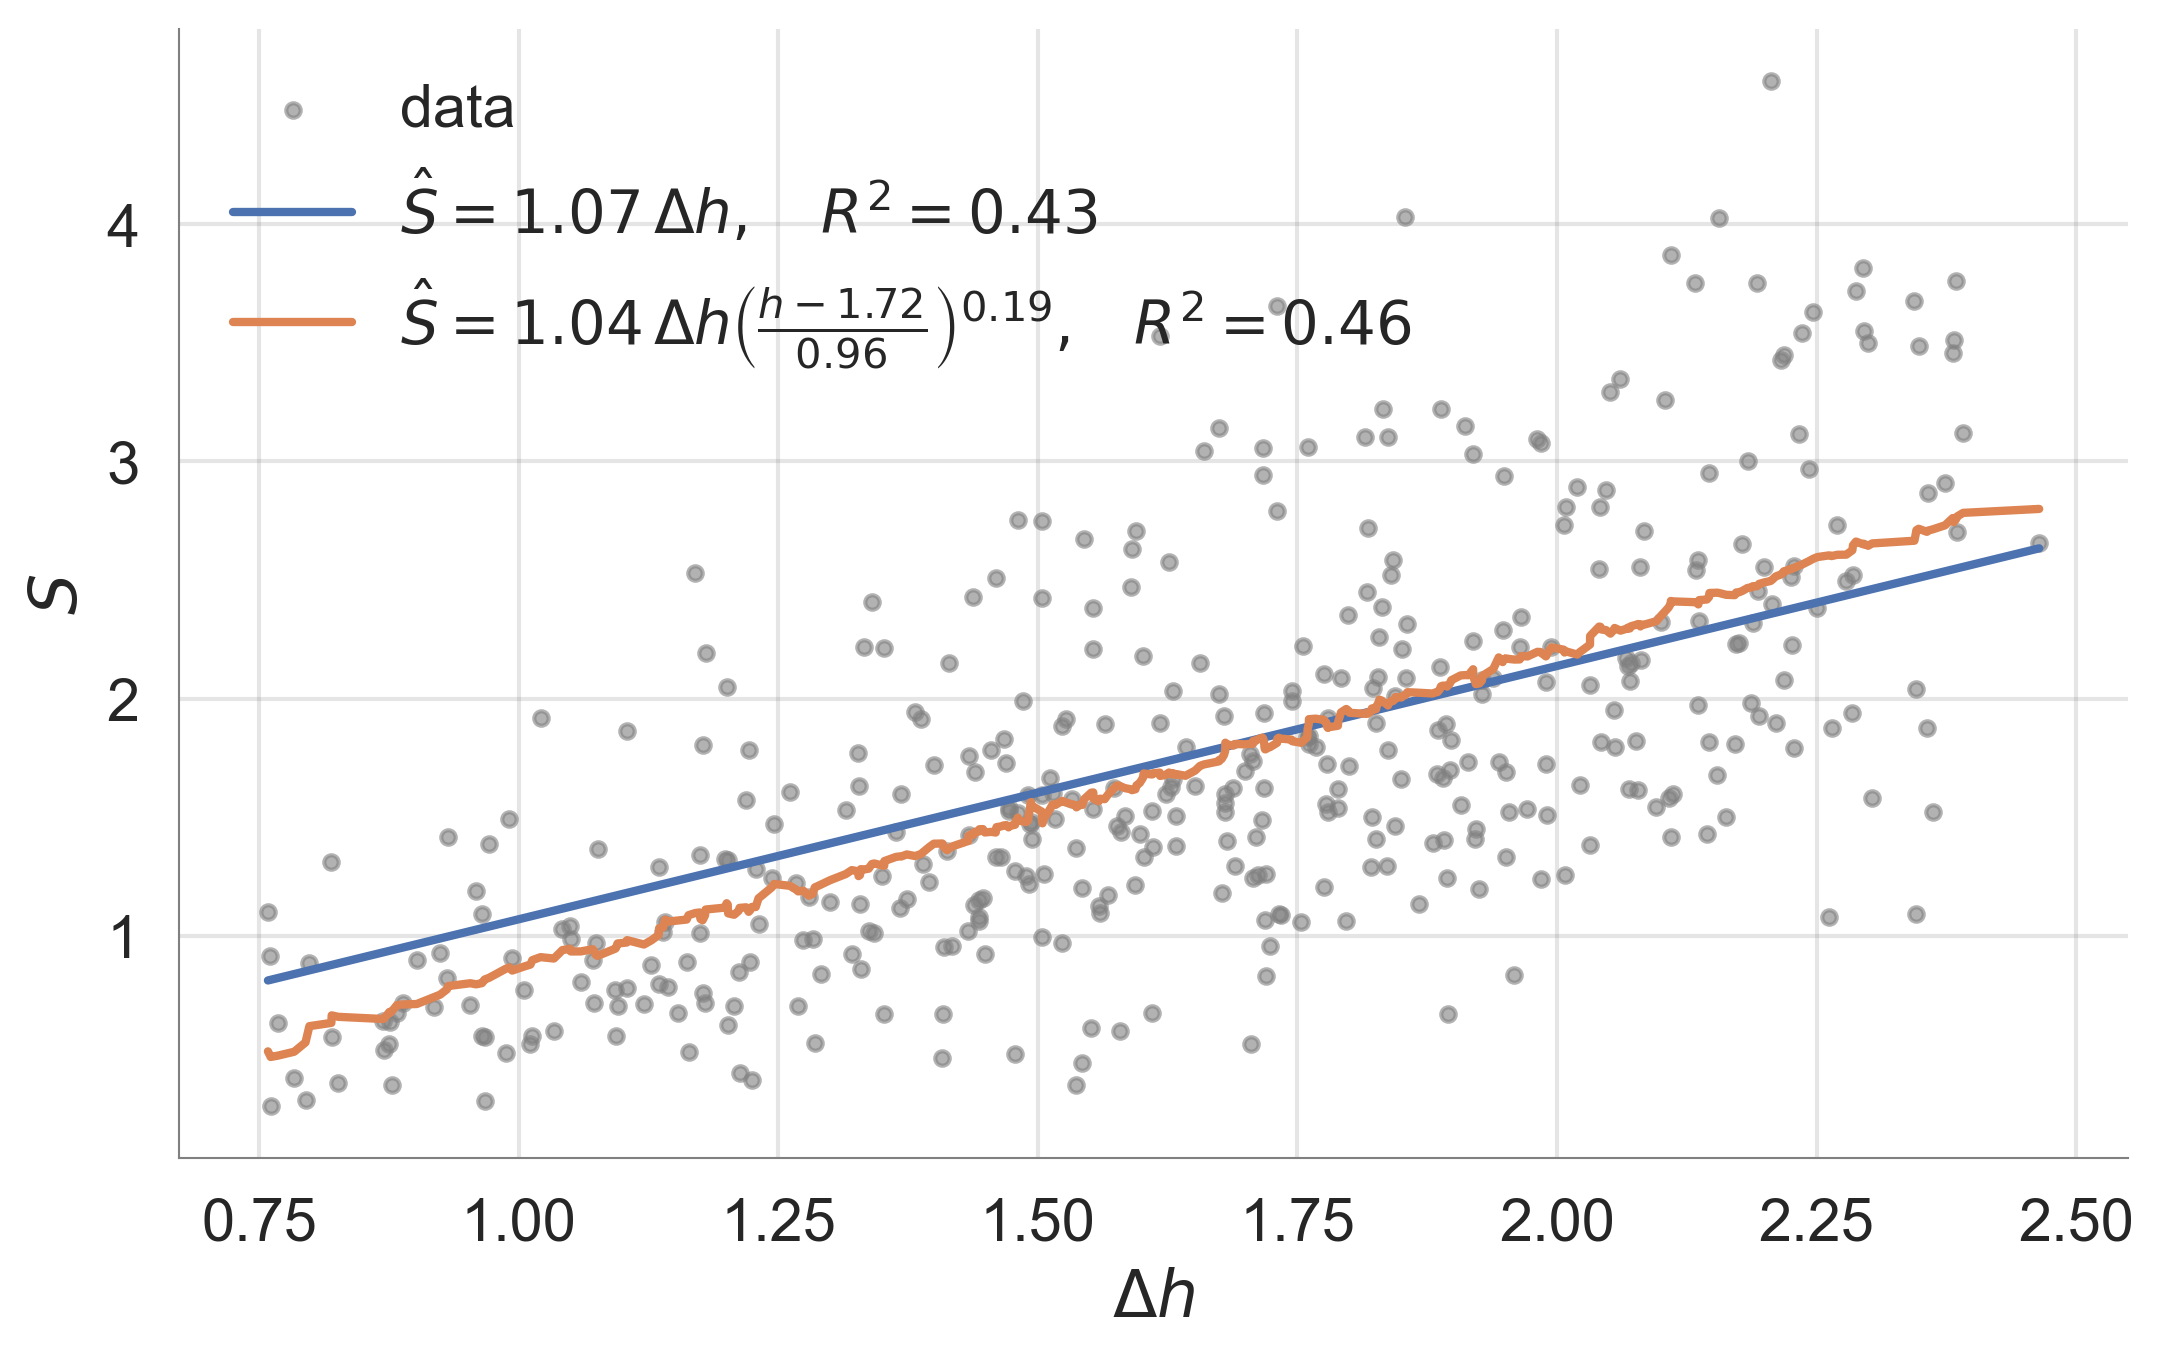

In [40]:
# subset for the panel
df_sub = df.query("delta_h < 2.5 and delta_h > 0.75")

# data arrays
x_all = df_sub["delta_h"].to_numpy(float)
y_all = df_sub["seepage"].to_numpy(float)
h_all = df_sub["visitor_h"].to_numpy(float)

# sort by Δh for clean lines
order = np.argsort(x_all)
xs = x_all[order]
hs = h_all[order]

# pooled params
C_lin   = float(pooled_lin["C"])

C_vis   = float(pooled_vis["C"])
off_vis = float(pooled_vis["offset"])
b_vis   = float(pooled_vis["b"])

# predictions
ys_lin = model_linear(C_lin, xs)
ys_vis = model_offset_power_visitor_h(C_vis, off_vis, b_vis, xs, hs, visitor_h_ref)

# optional smoothing of visitor curve for visualization only
try:
    from scipy.signal import savgol_filter
    w = max(7, int(0.02 * len(xs)) | 1)            # odd window ~2% of length
    ys_vis_plot = savgol_filter(ys_vis, w, polyorder=2, mode="interp")
except Exception:
    ys_vis_plot = ys_vis

# compute centered R2 on the same subset
r2_lin = r2_centered(y_all, model_linear(C_lin, x_all))
r2_vis = r2_centered(y_all, model_offset_power_visitor_h(C_vis, off_vis, 
                                                         b_vis, x_all, h_all, visitor_h_ref))

# helper to format ±offset in LaTeX cleanly
def fmt_pm(x):
    s = "+" if x >= 0 else "−"  # use true minus for TeX
    return s, abs(x)

# labels (TeX-safe, with ± and R2)
pm_vis, off_abs_vis = fmt_pm(off_vis)

lab_lin = rf"$\hat S = {C_lin:.2f}\,\Delta h, \quad R^2={r2_lin:.2f}$"

# visitor model: ((h_est + offset) / h_ref)^b  → write as (h_est ± |off|)/h_ref
lab_vis = (
    rf"$\hat S = {C_vis:.2f}\,\Delta h"
    r"\left(\frac{h_{\rm est}" + f" {pm_vis} " 
    + f"{off_abs_vis:.2f}" + r"}{h_{\rm ref}}\right)^{"
    + f"{b_vis:.2f}" + rf"}}, \quad \!R^2={r2_vis:.2f}$"
)

lab_vis  = (
    rf"$\hat S = {C_vis:.2f}\,\Delta h"
    r"\left(\frac{ h" + f"{off_vis:.2f}" + r"}{" + f"{(visitor_h_ref + off_vis):.2f}"
    + r"}\right)^{"
    + f"{b_vis:.2f}" + rf"}}, \quad \!R^2={r2_vis:.2f}$"
)

# plot
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(x_all, y_all, s=12, c="0.5", alpha=0.6, label="data")
ax.plot(xs, ys_lin, lw=2, label=lab_lin)
ax.plot(xs, ys_vis_plot, lw=2, label=lab_vis)

ax.set_xlabel(r"$\Delta h$")
ax.set_ylabel(r"$S$")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

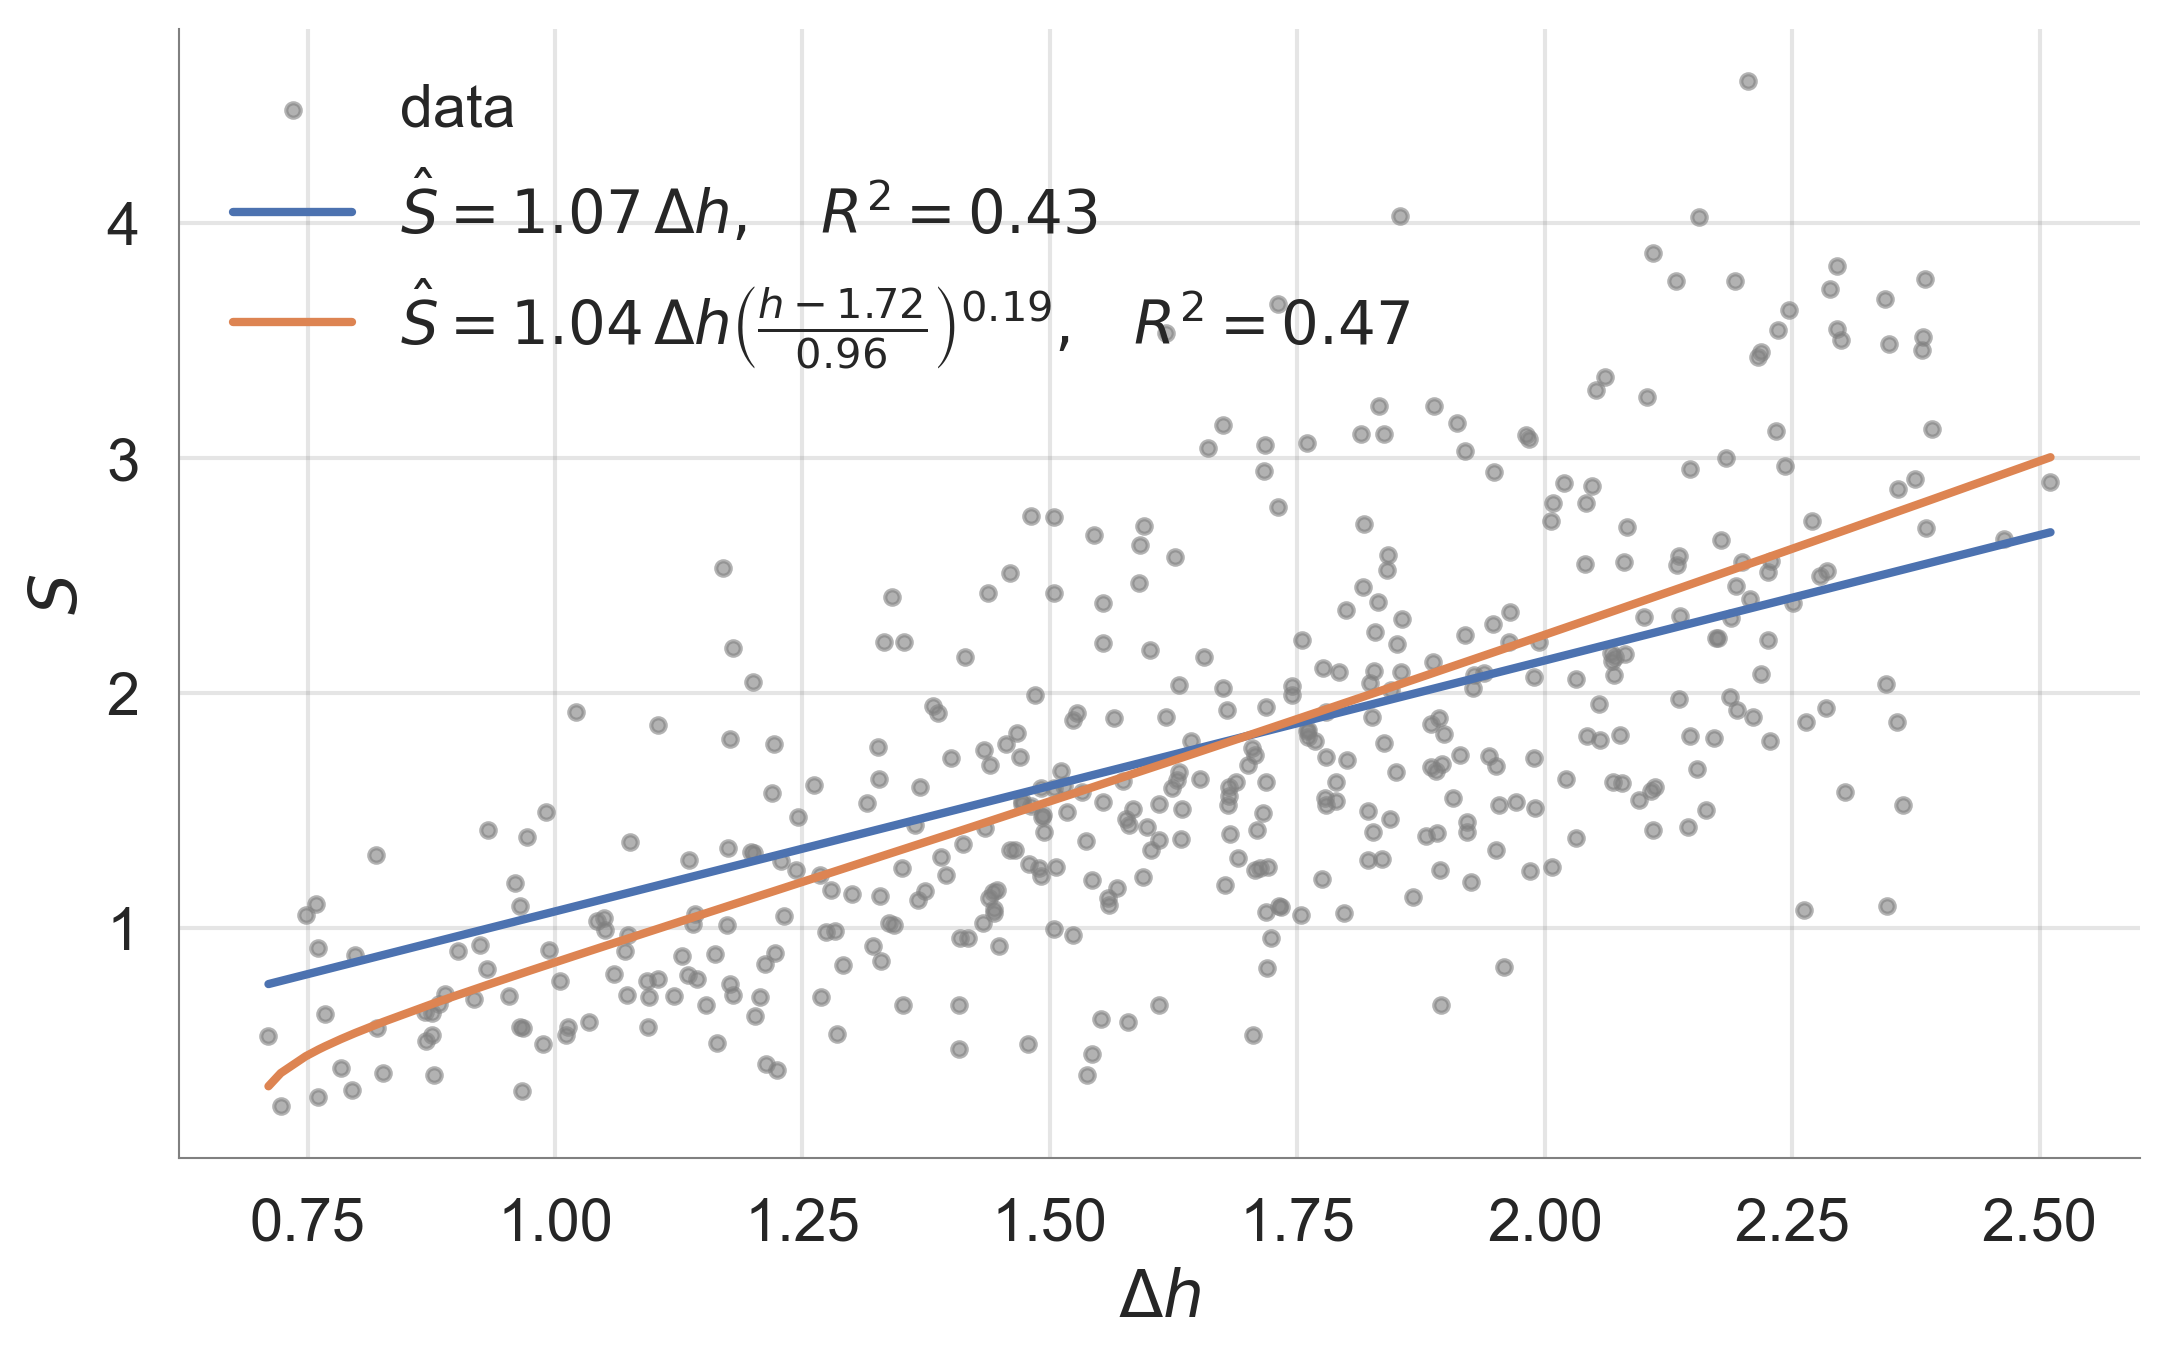

In [41]:

# subset for the panel
df_sub = df.query("delta_h < 2.6 and delta_h > 0.5").copy()

# data arrays
x_all = df_sub["delta_h"].to_numpy(float)
y_all = df_sub["seepage"].to_numpy(float)
h_all = df_sub["visitor_h"].to_numpy(float)

# --- regression: visitor_h as a function of Δh (h ≈ a_h + b_h * Δh) ---
a_h, b_h = np.polyfit(x_all, h_all, 1)

def h_hat(delta_h):
    """Estimated visitor_h from regression h ≈ a_h + b_h * Δh."""
    return a_h + b_h * delta_h

# sort by Δh for clean lines
order = np.argsort(x_all)
xs = x_all[order]
h_all = h_all[order]

# estimated h for sorted xs (for plotting) and full array (for R²)
hs_hat_s   = h_hat(xs)
hs_hat_all = h_hat(x_all)

# pooled params
C_lin   = float(pooled_lin["C"])

C_vis   = float(pooled_vis["C"])
off_vis = float(pooled_vis["offset"])
b_vis   = float(pooled_vis["b"])

# predictions USING h_hat instead of raw visitor_h
ys_lin = model_linear(C_lin, xs)
ys_vis = model_offset_power_visitor_h(
    C_vis, off_vis, b_vis, xs, hs_hat_s, visitor_h_ref
)

# centered R² on the same subset, also using h_hat
r2_lin = r2_centered(y_all, model_linear(C_lin, x_all))

r2_vis = r2_centered(
    y_all, 
    model_offset_power_visitor_h(C_vis, off_vis, b_vis, x_all, h_all, visitor_h_ref))


lab_vis = (
    rf"$\hat S = {C_vis:.2f}\,\Delta h"
    r"\left(\frac{h_{\rm est}" + f" {pm_vis} " 
    + f"{off_abs_vis:.2f}" + r"}{h_{\rm ref}}\right)^{"
    + f"{b_vis:.2f}" + rf"}}, \quad \!R^2={r2_vis:.2f}$"
)

lab_vis  = (
    rf"$\hat S = {C_vis:.2f}\,\Delta h"
    r"\left(\frac{ h" + f"{off_vis:.2f}" + r"}{" + f"{(visitor_h_ref + off_vis):.2f}"
    + r"}\right)^{"
    + f"{b_vis:.2f}" + rf"}}, \quad \!R^2={r2_vis:.2f}$"
)

# plot
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(x_all, y_all, s=12, c="0.5", alpha=0.6, label="data")
ax.plot(xs, ys_lin, lw=2, label=lab_lin)
ax.plot(xs, ys_vis, lw=2, label=lab_vis)

ax.set_xlabel(r"$\Delta h$")
ax.set_ylabel(r"$S$")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Top events (by n): [0, 2, 1]


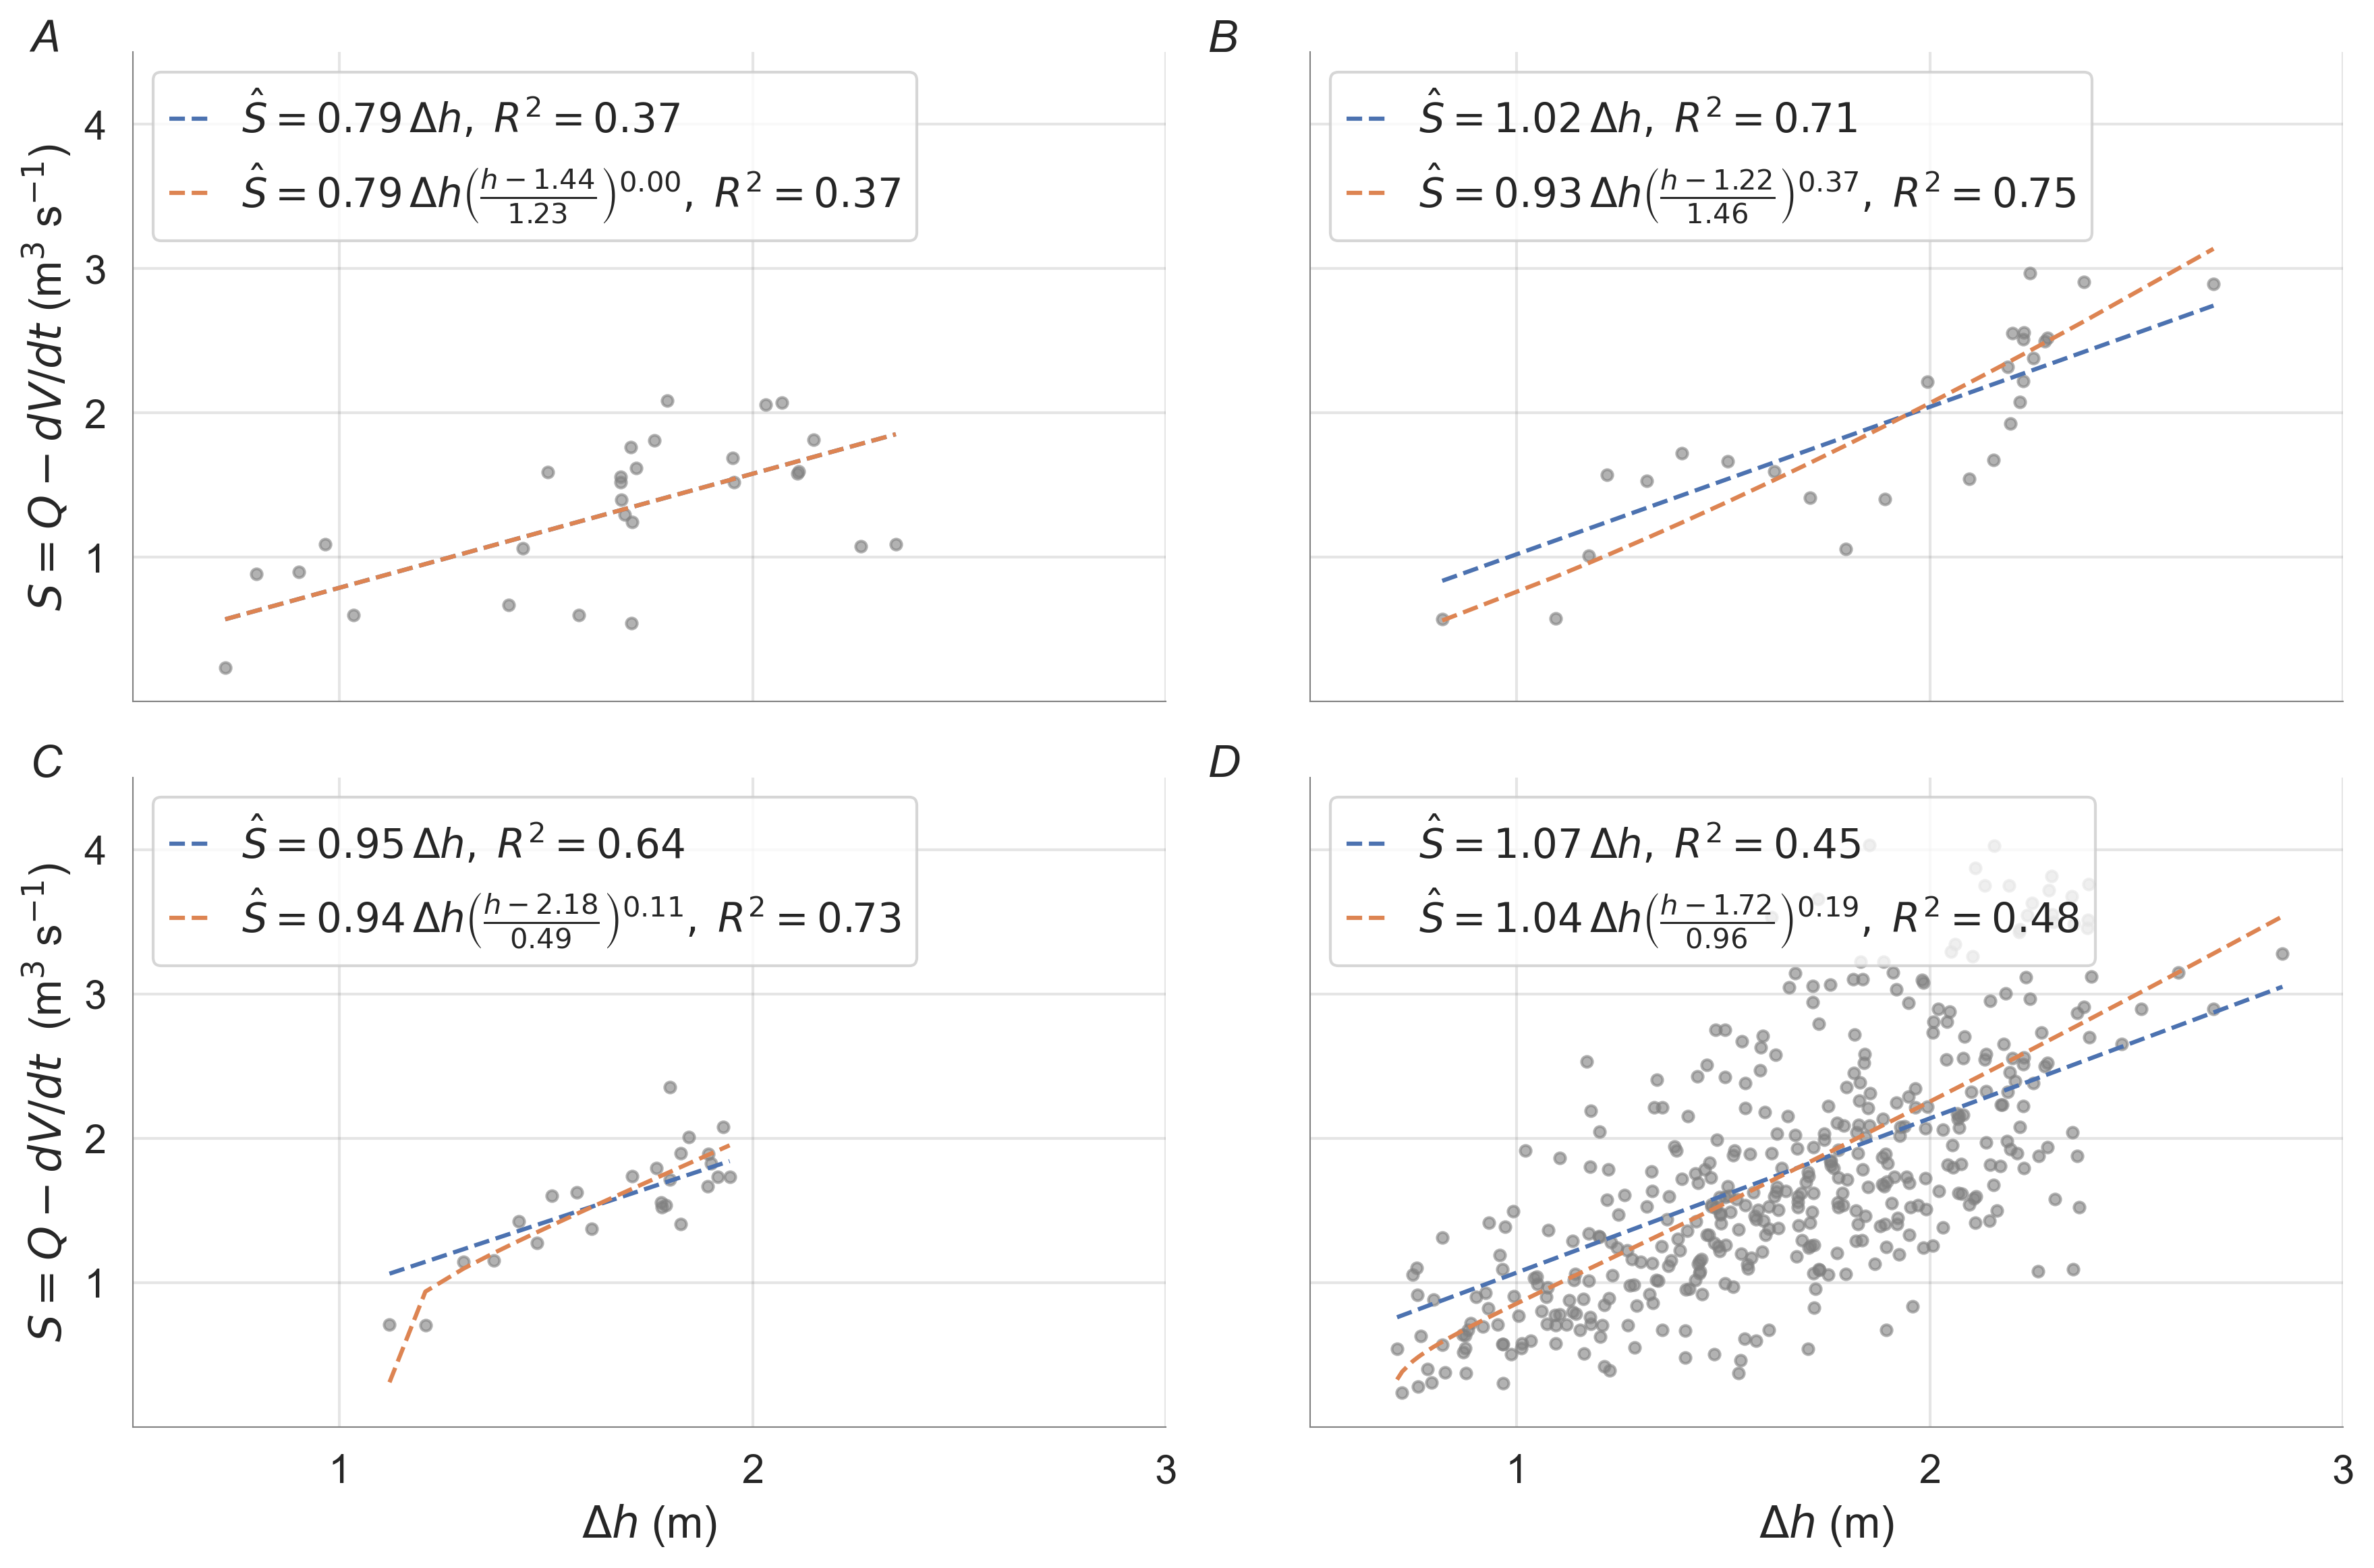

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize  # already imported above, but safe

x_reg = df["delta_h"].to_numpy(float)
h_reg = df["visitor_h"].to_numpy(float)

# regression: visitor_h ≈ a_h + b_h * Δh
a_h, b_h = np.polyfit(x_reg, h_reg, 1)

def h_hat(delta_h):
    """Global regression of visitor_h on Δh, used only for plotting."""
    return a_h + b_h * delta_h


# 2) Fit helpers: refit both models to a given subset ---------------
def fit_models_for_subset(df_evt):
    """Refit linear and visitor models on df_evt (uses visitor_h for fitting)."""

    x = df_evt["delta_h"].to_numpy(float)
    y = df_evt["seepage"].to_numpy(float)
    h = df_evt["visitor_h"].to_numpy(float)

    if len(x) == 0:
        return (np.nan,) * 6

    # Linear through-origin fit: S = C * Δh
    denom = max(np.dot(x, x), eps)
    C_lin_evt = float(np.dot(x, y) / denom)
    C_lin_evt = max(C_lin_evt, 1e-12)
    yhat_lin = model_linear(C_lin_evt, x)
    r2_lin_evt = r2_centered(y, yhat_lin)

    # Visitor model fit: S = C * Δh * ((h + offset)/(h_ref + offset))^b
    C0 = C_lin_evt
    off0 = (offset_lb_vis + offset_ub_vis) / 2
    b0 = 0.5

    res = minimize(
        sse_offset_power_visitor_h,
        x0=[C0, off0, b0],
        args=(x, h, y, visitor_h_ref, offset_lb_vis, offset_ub_vis),
        bounds=[(1e-12, None), (offset_lb_vis, offset_ub_vis), (1e-12, None)],
    )

    C_vis_evt, off_vis_evt, b_vis_evt = map(float, res.x)
    yhat_vis = model_offset_power_visitor_h(
        C_vis_evt, off_vis_evt, b_vis_evt, x, h, visitor_h_ref
    )
    r2_vis_evt = r2_centered(y, yhat_vis)

    return C_lin_evt, r2_lin_evt, C_vis_evt, off_vis_evt, b_vis_evt, r2_vis_evt

# 3) Plot helper for one panel --------------------------------------
def plot_event_panel(df_evt, ax, panel_label=None):
    # refit on this subset
    C_lin_evt, r2_lin_evt, C_vis_evt, off_vis_evt, b_vis_evt, r2_vis_evt = (
        fit_models_for_subset(df_evt)
    )

    x = df_evt["delta_h"].to_numpy(float)
    y = df_evt["seepage"].to_numpy(float)

    order = np.argsort(x)
    xs = x[order]

    # scatter
    ax.scatter(x, y, s=15, c="0.5", alpha=0.6, label="")

    # linear line
    ys_lin = model_linear(C_lin_evt, xs)

    # visitor line uses h_hat(xs) just for smoothness;
    # fit itself used visitor_h in fit_models_for_subset
    ys_vis = model_offset_power_visitor_h(
        C_vis_evt, off_vis_evt, b_vis_evt, xs, h_hat(xs), visitor_h_ref
    )

    # labels (same form as your second image)
    lab_lin = rf"$\hat S = {C_lin_evt:.2f}\,\Delta h, \; R^2={r2_lin_evt:.2f}$"
    sign = "-" if off_vis_evt < 0 else "+"
    off_abs = abs(off_vis_evt)
    lab_vis = (
        rf"$\hat S = {C_vis_evt:.2f}\,\Delta h"
        r"\left(\frac{h"+ sign  + f"{off_abs:.2f}" + r"}{"
        + f"{visitor_h_ref + off_vis_evt: .2f}" + r"}\right)^{" + f"{b_vis_evt:.2f}"
        + r"}, \; R^2=" + f"{r2_vis_evt:.2f}$"
    )

    ax.plot(xs, ys_lin, "--", color="C0", label=lab_lin)
    ax.plot(xs, ys_vis, "--", color="C1", label=lab_vis)

    #ax.axhline(0, c="k", lw=1)
    ax.legend(loc="upper left", handlelength=1)

    if panel_label is not None:
        ax.text(
            -0.1, 1.05, panel_label,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=16, style="italic"
        )

# 4) Choose three longest events within df ----------------------
event_lengths = df.groupby("event")["n"].max()
top_events = event_lengths.sort_values(ascending=False).index[[0, 1, 2]].tolist()
print("Top events (by n):", top_events)

# 5) Build 4-panel figure: A–C = three longest, D = pooled ----------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for eid, ax, lbl in zip(top_events, axes[:3], ["A", "B", "C"]):
    df_evt = df[df["event"] == eid].copy()
    plot_event_panel(df_evt, ax, panel_label=lbl)

# panel D: pooled over all events in df
plot_event_panel(df, axes[3], panel_label="D")

# common axes styling
for ax in axes:
    ax.set_xlim(0.5, 2.6)
    ax.set_ylim(0.0, 4.5)
    ax.set_xticks([1, 2, 3])
    ax.set_yticks([1, 2, 3, 4])
    ax.grid(alpha=0.2)

axes[0].set_ylabel(r"$S = Q - dV/dt$ (m$^3$ s$^{-1}$)")
axes[2].set_ylabel(r"$S = Q - dV/dt$  (m$^3$ s$^{-1}$)")
axes[2].set_xlabel(r"$\Delta h$ (m)")
axes[3].set_xlabel(r"$\Delta h$ (m)")
# axes[0].set_ylim(-0.1, 4.5)
plt.tight_layout()
plt.show()


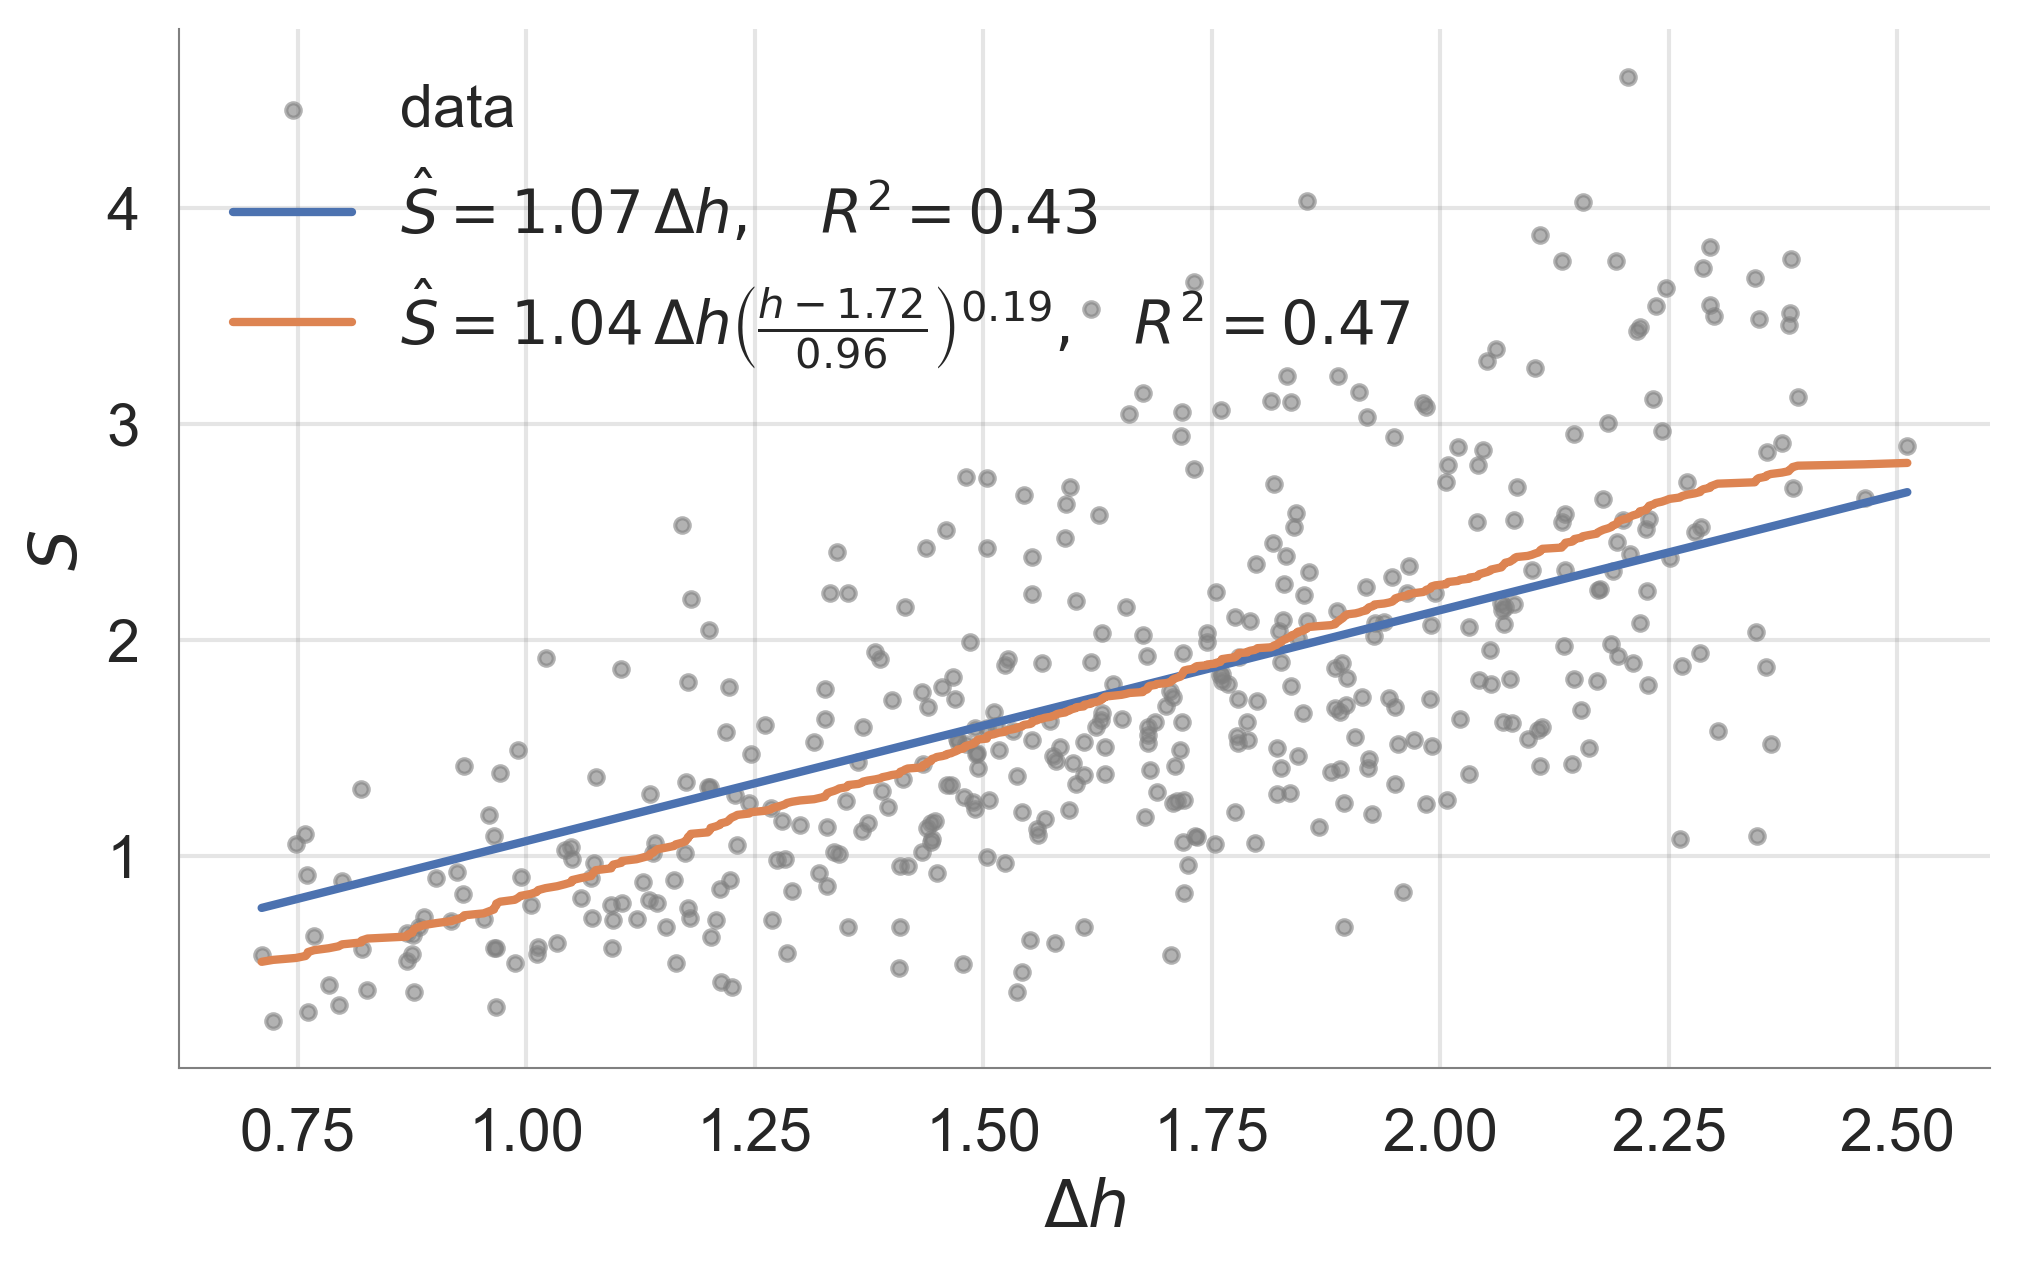

In [43]:
# --- smooth the visitor model line for visualization only ---
# Savitzky–Golay: smooth but preserves shape better than a boxcar
from scipy.signal import savgol_filter

# pick an odd window ~1–3% of series length, clamped
win = max(10, int(0.2 * len(xs)) | 1)   # ensure odd via bitwise or 1
win = min(win, len(xs) - (1 - len(xs) % 2))  # keep <= len(xs) and odd
ys_vis_smooth = savgol_filter(ys_vis, window_length=win, polyorder=1, mode="interp")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x_all, y_all, s=12, c="0.5", alpha=0.6, label="data")
ax.plot(xs, ys_lin, lw=2, label=lab_lin)
# ax.plot(xs, ys_dh,  lw=2, label=lab_dh)
ax.plot(xs, ys_vis_smooth, lw=2, label=lab_vis)   #  smoothed visitor curve

ax.set_xlabel(r"$\Delta h$")
ax.set_ylabel(r"$S$ ")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()

    